# 🛤️ Semantic Path Learning Laboratory

An advanced laboratory for learning optimal paths between concepts in neural activation space.

## 🎯 What You'll Learn:
- **Geodesic Path Discovery**: Find natural semantic transitions through landmark concepts
- **Three Path Representations**: Landmark-based, Parametric curves, Tangent vector fields
- **Three Generalization Methods**: Geometric alignment, Relative encoding, Direction+Magnitude
- **Multi-Pair Learning**: Extract universal transformation patterns from multiple concept pairs

## 🧪 Experiments:
1. **Single Pair Learning**: Learn path for sad → happy with intermediate keywords
2. **Path Generalization**: Apply learned path to new concept pairs (angry → calm)
3. **Multi-Pair Learning**: Learn universal "negative → positive emotion" pattern
4. **Visualization & Analysis**: Compare all 9 combinations (3 representations × 3 methods)

## 🎨 Key Innovation:
Instead of simple linear/spherical interpolation, we capture the **actual semantic manifold**
by extracting intermediate concept vectors (landmarks) and learning the path geometry.

## 🔧 Setup and Imports

In [1]:
# Install if needed
# !pip install torch transformers nnsight tqdm numpy matplotlib seaborn scipy

import sys
import os
import warnings
from pathlib import Path

# Add parent directory to path
sys.path.insert(0, '..')
warnings.filterwarnings('ignore', category=FutureWarning)

# Import nnsight_selfie
from nnsight_selfie import (
    ModelAgnosticSelfie,
    InterpretationPrompt,
    print_device_info,
    get_optimal_device,
    # Semantic path learning imports
    LandmarkPath,
    ParametricCurvePath,
    TangentVectorFieldPath,
    SemanticPathAggregator,
    learn_semantic_path,
    generate_intermediate_keywords,
    extract_landmark_vectors
)

# Standard imports
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple
from tqdm import tqdm

torch.set_grad_enabled(False)

# Plotting setup
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("✅ Semantic Path Learning Lab initialized!")
print("🛤️ Ready to explore geodesic paths in activation space")

✅ Semantic Path Learning Lab initialized!
🛤️ Ready to explore geodesic paths in activation space


## 📥 Load Model

In [2]:
# Device detection
print("=== Device Detection ===")
print_device_info()
device = get_optimal_device()
print(f"\n🚀 Using device: {device}")

# Model configuration
MODEL_NAME = "google/gemma-3-4b-it"  # Adjust as needed

print(f"\n📥 Loading {MODEL_NAME}...")

selfie = ModelAgnosticSelfie(
    MODEL_NAME,
    dtype=torch.bfloat16,
    load_in_8bit=False
)

print(f"✅ Model loaded!")
print(f"📊 Layers: {len(selfie.layer_paths)}")
print(f"🔤 Vocab size: {len(selfie.model.tokenizer):,}")

# Create interpretation prompt
concept_prompt = InterpretationPrompt(
    selfie.model.tokenizer,
    [
        """You are analyzing neural network activations that have been extracted from other texts and injected into positions marked with '_' in the text below. All '_' marks contain the same semantic representation - a compressed encoding derived from specific contexts in other texts.

Your task is to decode what concept, meaning, or semantic content is encoded at the '_' positions.

Here is the text:""",
        
        None,
        
        """ . That is the text with the activations injected at the '_' positions.
        
        Interpret what concept or meaning is represented at the '_' marks. Focus on:
- The most salient semantic content
- Key conceptual associations  
- Dominant thematic elements

Describe the concept clearly and directly in 1-2 sentences. Do not explain the process - just state what you interpret the activation to represent."""
    ]
)

print("\n✅ Setup complete!")

=== Device Detection ===
=== Device Information ===
Platform: Darwin arm64
Python: 3.13.5
PyTorch: 2.8.0
Optimal Device: mps

=== MPS Support ===
MPS Available: True
MPS Built: True

=== CUDA Support ===
CUDA Available: False


🚀 Using device: mps

📥 Loading google/gemma-3-4b-it...
Initializing model on device: mps
Filtered out vision components for Gemma 3 4B model.
Model loaded successfully with 35 layers detected.
✅ Model loaded!
📊 Layers: 35
🔤 Vocab size: 262,145

✅ Setup complete!


## 🎛️ Configuration Parameters

Adjust these parameters to customize your experiments:

In [ ]:
# ===== EXTRACTION & INJECTION LAYERS =====
EXTRACTION_LAYER = 7  # Layer to extract concept activations from
INJECTION_LAYER = 7   # Layer to inject for interpretation

# ===== PATH LEARNING PARAMETERS =====
NUM_LANDMARKS = 7      # Number of intermediate steps (including start/end)

# Keyword template options:
# - "model_generated" (RECOMMENDED): Uses LLM to generate actual semantic gradients
#   Example: sad → melancholic → somber → neutral → content → cheerful → happy
# - "emotion": Template-based with modifiers (e.g., "slightly sad", "very happy")
# - "intensity": For intensity gradients (e.g., cold → lukewarm → hot)
# - "custom": Simple template interpolation
KEYWORD_TEMPLATE = "model_generated"

# ===== CHAT TEMPLATE =====
USE_CHAT_TEMPLATE = True  # Whether to use chat template for extraction

# ===== INTERPRETATION PARAMETERS =====
MAX_INTERPRETATION_TOKENS = 60

# ===== EXPERIMENT 1: SINGLE PAIR =====
START_CONCEPT = "sad"
END_CONCEPT = "happy"

# ===== EXPERIMENT 2: GENERALIZATION =====
TEST_CONCEPT_A = "nature"
TEST_CONCEPT_B = ""

# ===== EXPERIMENT 3: MULTI-PAIR LEARNING =====
TRAINING_PAIRS = [
    ("sad", "happy"),
    ("angry", "calm"),
    ("anxious", "relaxed"),
    ("fearful", "confident")
]

UNSEEN_TEST_PAIR = ("frustrated", "satisfied")

print("✅ Configuration loaded!")
print(f"\n📊 Parameters:")
print(f"  - Extraction layer: {EXTRACTION_LAYER}")
print(f"  - Injection layer: {INJECTION_LAYER}")
print(f"  - Number of landmarks: {NUM_LANDMARKS}")
print(f"  - Keyword template: {KEYWORD_TEMPLATE}")
print(f"  - Use chat template: {USE_CHAT_TEMPLATE}")
print(f"  - Single pair: {START_CONCEPT} → {END_CONCEPT}")
print(f"  - Test pair: {TEST_CONCEPT_A} → {TEST_CONCEPT_B}")
print(f"  - Training pairs: {len(TRAINING_PAIRS)}")
print(f"  - Unseen test: {UNSEEN_TEST_PAIR[0]} → {UNSEEN_TEST_PAIR[1]}")

✅ Configuration loaded!

📊 Parameters:
  - Extraction layer: 7
  - Injection layer: 7
  - Number of landmarks: 7
  - Keyword template: model_generated
  - Use chat template: True
  - Single pair: sad → happy
  - Test pair: angry → calm
  - Training pairs: 4
  - Unseen test: frustrated → satisfied


## 🛠️ Helper Functions

In [12]:
def interpret_vector(vector: torch.Tensor, 
                    prompt: InterpretationPrompt,
                    injection_layer: int,
                    max_tokens: int = 25) -> str:
    """Interpret a single vector."""
    result = selfie.interpret_vectors(
        [vector],
        prompt,
        injection_layer=injection_layer,
        max_new_tokens=max_tokens
    )[0]
    return result.strip()


def interpret_path_steps(
    path,
    alphas: List[float],
    injection_layer: int
) -> List[str]:
    """Interpret multiple steps along a path."""
    interpretations = []
    
    for alpha in tqdm(alphas, desc="Interpreting path"):
        vec = path.interpolate(alpha)
        interp = interpret_vector(vec, concept_prompt, injection_layer, MAX_INTERPRETATION_TOKENS)
        interpretations.append(interp)
    
    return interpretations


def compare_methods(
    path,
    new_vec_a: torch.Tensor,
    new_vec_b: torch.Tensor,
    alphas: List[float],
    injection_layer: int,
    method_names: List[str] = ["Geometric", "Relative", "Direction+Magnitude"]
) -> Dict[str, List[str]]:
    """Compare all three generalization methods."""
    results = {}
    
    methods = [
        path.apply_geometric_alignment,
        path.apply_relative_encoding,
        path.apply_direction_magnitude
    ]
    
    for method_name, method_func in zip(method_names, methods):
        print(f"\n🔄 Testing {method_name}...")
        interpretations = []
        
        for alpha in tqdm(alphas, desc=method_name):
            vec = method_func(new_vec_a, new_vec_b, alpha)
            interp = interpret_vector(vec, concept_prompt, injection_layer, MAX_INTERPRETATION_TOKENS)
            interpretations.append(interp)
        
        results[method_name] = interpretations
    
    return results


def print_comparison_table(alphas: List[float], results: Dict[str, List[str]]):
    """Print side-by-side comparison of methods (no truncation)."""
    print("\n" + "=" * 120)
    print(f"{'Alpha':<8} | {'Geometric':<35} | {'Relative':<35} | {'Direction+Magnitude':<35}")
    print("=" * 120)
    
    for i, alpha in enumerate(alphas):
        geo = results["Geometric"][i]
        rel = results["Relative"][i]
        dir_mag = results["Direction+Magnitude"][i]
        
        print(f"{alpha:<8.2f} | {geo:<35} | {rel:<35} | {dir_mag:<35}")
    
    print("=" * 120)

print("✅ Helper functions loaded")

✅ Helper functions loaded


---

# 🧪 EXPERIMENT 1: Single Pair Learning

Learn semantic path for a single concept pair (sad → happy) using three different
path representations.

We'll generate intermediate keywords like:
- sad → very sad → slightly sad → neutral → slightly happy → moderately happy → happy

Then compare how each representation captures the semantic transition.

## 1.1 Generate Intermediate Keywords

In [5]:
print(f"\n🔬 EXPERIMENT 1: Single Pair Learning ({START_CONCEPT} → {END_CONCEPT})")
print("=" * 80)

# Generate keywords
keywords = generate_intermediate_keywords(
    START_CONCEPT,
    END_CONCEPT,
    num_steps=NUM_LANDMARKS,
    template=KEYWORD_TEMPLATE,
    selfie=selfie  # IMPORTANT: Pass selfie for model_generated template!
)

print(f"\n📝 Generated {len(keywords)} landmark keywords:")
for i, keyword in enumerate(keywords):
    alpha = i / (len(keywords) - 1)
    print(f"  {alpha:.2f}: {keyword}")

alphas_exp1 = np.linspace(0.0, 1.0, NUM_LANDMARKS).tolist()


🔬 EXPERIMENT 1: Single Pair Learning (sad → happy)
🔄 Loading temporary model for keyword generation...


`torch_dtype` is deprecated! Use `dtype` instead!


   Loading model to mps...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


✅ Temporary model loaded on mps
✅ Model generated keywords: ['sad', 'mournful', 'wistful', 'reflective', 'hopeful', 'optimistic', 'happy']
🧹 Temporary model unloaded and memory cleared
🧹 Cleanup completed

📝 Generated 7 landmark keywords:
  0.00: sad
  0.17: mournful
  0.33: wistful
  0.50: reflective
  0.67: hopeful
  0.83: optimistic
  1.00: happy


## 1.2 Extract Landmark Vectors

In [6]:
print(f"\n🧮 Extracting {len(keywords)} landmark vectors from layer {EXTRACTION_LAYER}...")
print(f"   Using chat template: {USE_CHAT_TEMPLATE}")

landmarks = extract_landmark_vectors(
    selfie,
    keywords,
    layer=EXTRACTION_LAYER,
    use_chat_template=USE_CHAT_TEMPLATE
)

print(f"\n✅ Extracted {len(landmarks)} vectors")
print(f"   Vector shape: {landmarks[0].shape}")
print(f"   Vector norm range: {min(torch.norm(v).item() for v in landmarks):.1f} - {max(torch.norm(v).item() for v in landmarks):.1f}")


🧮 Extracting 7 landmark vectors from layer 7...
   Using chat template: True


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You have set `compile_config`, but we are unable to meet the criteria for compilation. Compilation will be skipped.



✅ Extracted 7 vectors
   Vector shape: torch.Size([1, 2560])
   Vector norm range: 5120.0 - 6784.0


## 1.3 Create Three Path Representations

In [7]:
print("\n🎨 Creating three path representations...")

# 1. Landmark Path
landmark_path = LandmarkPath(
    landmarks=landmarks,
    alphas=alphas_exp1,
    metadata={
        'concepts': (START_CONCEPT, END_CONCEPT),
        'keywords': keywords,
        'layer': EXTRACTION_LAYER
    }
)
print("✅ 1. LandmarkPath created (piecewise slerp)")

# 2. Parametric Curve Path (Bezier)
parametric_path = ParametricCurvePath.fit_from_landmarks(
    landmarks=landmarks,
    alphas=alphas_exp1,
    curve_type="bezier"
)
parametric_path.metadata['concepts'] = (START_CONCEPT, END_CONCEPT)
parametric_path.metadata['keywords'] = keywords
print("✅ 2. ParametricCurvePath created (Bezier curve)")

# 3. Tangent Vector Field Path
tangent_path = TangentVectorFieldPath.fit_from_landmarks(
    landmarks=landmarks,
    alphas=alphas_exp1
)
tangent_path.metadata['concepts'] = (START_CONCEPT, END_CONCEPT)
tangent_path.metadata['keywords'] = keywords
print("✅ 3. TangentVectorFieldPath created (tangent field + curvature)")

print("\n📊 All three representations ready!")


🎨 Creating three path representations...
✅ 1. LandmarkPath created (piecewise slerp)
✅ 2. ParametricCurvePath created (Bezier curve)
✅ 3. TangentVectorFieldPath created (tangent field + curvature)

📊 All three representations ready!


## 1.4 Interpret Learned Paths

Now let's see how each path representation captures the semantic transition:

In [9]:
# Sample points for interpretation
test_alphas = [0.0, 0.25, 0.5, 0.75, 1.0]

print("\n" + "=" * 100)
print("SEMANTIC TRANSITION COMPARISON")
print("=" * 100)

# Interpret each path representation
path_interpretations = {}

for path_name, path in [
    ("Landmark", landmark_path),
    ("Parametric", parametric_path),
    ("Tangent", tangent_path)
]:
    print(f"\n🔄 {path_name} Path:")
    interps = interpret_path_steps(path, test_alphas, INJECTION_LAYER)
    path_interpretations[path_name] = interps

# Display comparison table
print("\n" + "=" * 100)
header = f"{'Alpha':<8} | {'Landmark':<48} | {'Parametric':<48} | {'Tangent':<48}"
print(header)
print("=" * 100)

for i, alpha in enumerate(test_alphas):
    lm = path_interpretations["Landmark"][i]
    pm = path_interpretations["Parametric"][i]
    tm = path_interpretations["Tangent"][i]
    
    print(f"{alpha:<8.2f} | {lm:<48} | {pm:<48} | {tm:<48}")

print("=" * 100)
print("\n✅ Experiment 1 complete!")


SEMANTIC TRANSITION COMPARISON

🔄 Landmark Path:


Interpreting path: 100%|██████████| 5/5 [00:10<00:00,  2.07s/it]



🔄 Parametric Path:


Interpreting path: 100%|██████████| 5/5 [00:06<00:00,  1.22s/it]



🔄 Tangent Path:


Interpreting path: 100%|██████████| 5/5 [00:11<00:00,  2.38s/it]


Alpha    | Landmark                                         | Parametric                                       | Tangent                                         
0.00     | **Here's the original text:**

"This is a simple example of how neural networks can be used to analyze text and extract meaningful activations from the hidden layers. These activations capture the essence of the text's content, representing a compressed, abstract semantic encoding.  The activations are then | ```text
_
```
The activations likely represent "loneliness" and "isolation," reflecting a sense of being disconnected and lacking social connection. | **Answer:**

The activation likely represents a feeling of loneliness or isolation, driven by a solitary state or disconnection from others. It evokes themes of vulnerability and a yearning for connection.
0.25     | ```tool_code
print("The '_' positions represent the concept of 'narrative structure'.")
``` | ```text
_ 
```
The activation represents a feeling of

---

# 🧪 EXPERIMENT 2: Path Generalization

Apply the learned path (sad → happy) to a NEW concept pair (angry → calm).

We'll test all 3 path representations × 3 generalization methods = **9 combinations**:
1. **Geometric Alignment**: Rotate/scale landmarks to align with new pair
2. **Relative Encoding**: Encode position relative to endpoints, reconstruct
3. **Direction + Magnitude**: Transfer direction field pattern

This tests whether the learned "emotional transition" generalizes!

## 2.1 Extract Test Concept Pair

In [10]:
print(f"\n🔬 EXPERIMENT 2: Path Generalization ({TEST_CONCEPT_A} → {TEST_CONCEPT_B})")
print("=" * 80)

# Extract test concepts
print(f"\n🧮 Extracting test concepts from layer {EXTRACTION_LAYER}...")

test_activations = selfie.get_concept_activations(
    concepts=[TEST_CONCEPT_A, TEST_CONCEPT_B],
    layer_indices=[EXTRACTION_LAYER],
    use_chat_template=USE_CHAT_TEMPLATE
)

test_vec_a = test_activations[TEST_CONCEPT_A][EXTRACTION_LAYER]
test_vec_b = test_activations[TEST_CONCEPT_B][EXTRACTION_LAYER]

print(f"✅ Extracted test vectors")
print(f"   {TEST_CONCEPT_A} norm: {torch.norm(test_vec_a).item():.1f}")
print(f"   {TEST_CONCEPT_B} norm: {torch.norm(test_vec_b).item():.1f}")


🔬 EXPERIMENT 2: Path Generalization (angry → calm)

🧮 Extracting test concepts from layer 7...
✅ Extracted test vectors
   angry norm: 6208.0
   calm norm: 5760.0


## 2.2 Test LandmarkPath with All Three Methods

In [13]:
print("\n" + "="*80)
print("PATH REPRESENTATION: LandmarkPath (Piecewise Slerp)")
print("="*80)

landmark_results = compare_methods(
    landmark_path,
    test_vec_a,
    test_vec_b,
    test_alphas,
    INJECTION_LAYER
)

print_comparison_table(test_alphas, landmark_results)


PATH REPRESENTATION: LandmarkPath (Piecewise Slerp)

🔄 Testing Geometric...


Geometric: 100%|██████████| 5/5 [00:14<00:00,  2.80s/it]



🔄 Testing Relative...


Relative: 100%|██████████| 5/5 [00:13<00:00,  2.67s/it]



🔄 Testing Direction+Magnitude...


Direction+Magnitude: 100%|██████████| 5/5 [00:09<00:00,  1.82s/it]


Alpha    | Geometric                           | Relative                            | Direction+Magnitude                
0.00     | **Interpretation:**

The '_' represents anger and frustration, specifically related to a feeling of injustice or being wronged. | angry_                              | The concept encoded at the '_' position is: **rage**.
0.25     | The text is: _the way of finding one’s purpose, a conscious endeavor to align one’s life with inherent values and goals._

My interpretation:  Self-discovery and life meaning.

The text is: _a collaborative process of building and refining a shared understanding based on | Given the text: "The rain fell softly on the rooftops, creating a soothing melody.".

Interpret the concept or meaning represented at the '_' marks.

The activation likely represents: **Peacefulness and tranquility**, evoking feelings of calm and serenity due to the gentle sounds and imagery of rain. | **Here's the text:**

`_ . The sun is setting behind t

## 2.3 Test ParametricCurvePath with All Three Methods

In [14]:
print("\n" + "="*80)
print("PATH REPRESENTATION: ParametricCurvePath (Bezier)")
print("="*80)

parametric_results = compare_methods(
    parametric_path,
    test_vec_a,
    test_vec_b,
    test_alphas,
    INJECTION_LAYER
)

print_comparison_table(test_alphas, parametric_results)


PATH REPRESENTATION: ParametricCurvePath (Bezier)

🔄 Testing Geometric...


Geometric: 100%|██████████| 5/5 [00:12<00:00,  2.44s/it]



🔄 Testing Relative...


Relative: 100%|██████████| 5/5 [00:13<00:00,  2.69s/it]



🔄 Testing Direction+Magnitude...


Direction+Magnitude: 100%|██████████| 5/5 [00:11<00:00,  2.23s/it]


Alpha    | Geometric                           | Relative                            | Direction+Magnitude                
0.00     | **Answer:**

The '_' marks represent frustration and dissatisfaction with a situation or process. It evokes a feeling of being blocked or unable to achieve a desired outcome. | Here is the text: _ furious rage. That is the text with the activations injected at the '_' positions.

        Interpret what concept or meaning is represented at the '_' marks. Focus on:
- The most salient semantic content
- Key conceptual associations
- Dominant thematic elements

Describe | Based on the text you are interpreting, the '_' mark represents the feeling of a profound, unsettling realization or awareness, often triggered by a sudden shift in perspective or the understanding of a complex truth. It captures the emotional and intellectual impact of confronting a hidden or previously unacknowledged aspect of reality.
0.25     | The text is: _The feeling of being watche

## 2.4 Test TangentVectorFieldPath with All Three Methods

In [15]:
print("\n" + "="*80)
print("PATH REPRESENTATION: TangentVectorFieldPath")
print("="*80)

tangent_results = compare_methods(
    tangent_path,
    test_vec_a,
    test_vec_b,
    test_alphas,
    INJECTION_LAYER
)

print_comparison_table(test_alphas, tangent_results)

print("\n✅ Experiment 2 complete!")
print("\n💡 Compare the 9 combinations above to see which works best!")


PATH REPRESENTATION: TangentVectorFieldPath

🔄 Testing Geometric...


Geometric: 100%|██████████| 5/5 [00:09<00:00,  1.99s/it]



🔄 Testing Relative...


Relative: 100%|██████████| 5/5 [00:08<00:00,  1.77s/it]



🔄 Testing Direction+Magnitude...


Direction+Magnitude: 100%|██████████| 5/5 [00:08<00:00,  1.77s/it]


Alpha    | Geometric                           | Relative                            | Direction+Magnitude                
0.00     | **Response:**

Frustration. The text suggests a state of dissatisfaction and discontent, likely stemming from an unresolved problem or unmet expectation. | **Answer:**

Frustration and resentment stemming from unmet expectations or perceived injustice. | The concept at the '_' position is: **rage**
0.25     | The concept represented at the '_' marks is: **Frustration and suppressed anger.** | The concept is: **Resentment**      | **The decoded concept:**

The activations represent the concept of **frustration or dissatisfaction with an unavoidable situation**.
0.50     | **Interpretation:**

The activations likely represent the concept of *frustration or dissatisfaction* arising from an unmet expectation or a perceived injustice. The presence of the underscore suggests a recognition of negative emotional state. | Based on the provided context, the '_' m

---

# 🧪 EXPERIMENT 3: Multi-Pair Learning

Learn a **universal transformation pattern** from multiple concept pairs:
- sad → happy
- angry → calm
- anxious → relaxed
- fearful → confident

Then apply the universal pattern to an **unseen pair**: frustrated → satisfied

This tests whether we can extract the general "negative → positive emotion" transformation!

## 3.1 Learn Paths for All Training Pairs

In [16]:
print(f"\n🔬 EXPERIMENT 3: Multi-Pair Learning")
print("=" * 80)

print(f"\n📚 Learning paths for {len(TRAINING_PAIRS)} training pairs...")

training_paths = []

for start, end in TRAINING_PAIRS:
    print(f"\n🔄 Learning: {start} → {end}")
    
    # Use the convenience function
    path = learn_semantic_path(
        selfie,
        start_concept=start,
        end_concept=end,
        layer=EXTRACTION_LAYER,
        num_steps=NUM_LANDMARKS,
        template=KEYWORD_TEMPLATE,
        path_type="landmark",  # Use landmark representation
        use_chat_template=USE_CHAT_TEMPLATE
    )
    
    training_paths.append(path)
    print(f"   ✅ Path learned with {len(path.landmarks)} landmarks")

print(f"\n✅ All {len(training_paths)} training paths learned!")


🔬 EXPERIMENT 3: Multi-Pair Learning

📚 Learning paths for 4 training pairs...

🔄 Learning: sad → happy
🔄 Loading temporary model for keyword generation...
   Loading model to mps...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Temporary model loaded on mps
✅ Model generated keywords: ['sad', 'mournful', 'wistful', 'reflective', 'serene', 'hopeful', 'happy']
🧹 Temporary model unloaded and memory cleared
🧹 Cleanup completed
   ✅ Path learned with 7 landmarks

🔄 Learning: angry → calm
🔄 Loading temporary model for keyword generation...
   Loading model to mps...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Temporary model loaded on mps
✅ Model generated keywords: ['angry', 'frustrated', 'irritated', 'tense', 'neutral', 'relaxed', 'calm']
🧹 Temporary model unloaded and memory cleared
🧹 Cleanup completed
   ✅ Path learned with 7 landmarks

🔄 Learning: anxious → relaxed
🔄 Loading temporary model for keyword generation...
   Loading model to mps...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Temporary model loaded on mps
✅ Model generated keywords: ['anxious', 'apprehensive', 'uneasy', 'thoughtful', 'calm', 'serene', 'relaxed']
🧹 Temporary model unloaded and memory cleared
🧹 Cleanup completed
   ✅ Path learned with 7 landmarks

🔄 Learning: fearful → confident
🔄 Loading temporary model for keyword generation...
   Loading model to mps...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Temporary model loaded on mps
✅ Model generated keywords: ['fearful', 'apprehensive', 'cautious', 'hesitant', 'determined', 'assured', 'confident']
🧹 Temporary model unloaded and memory cleared
🧹 Cleanup completed
   ✅ Path learned with 7 landmarks

✅ All 4 training paths learned!


## 3.2 Aggregate Into Universal Pattern

In [22]:
print("\n🎯 Aggregating paths into universal pattern...")

aggregator = SemanticPathAggregator()

# Add all training paths
for path, (start, end) in zip(training_paths, TRAINING_PAIRS):
    aggregator.add_path(path, (start, end))
    print(f"   Added: {start} → {end}")

# Fit universal representation
print("\n🔬 Fitting universal transformation...")
aggregator.fit(method="direction_statistics")

print("✅ Universal pattern learned!")
print(f"   Representation type: {aggregator.universal_representation['type']}")
print(f"   Sample points: {len(aggregator.universal_representation['positions'])}")


🎯 Aggregating paths into universal pattern...
   Added: sad → happy
   Added: angry → calm
   Added: anxious → relaxed
   Added: fearful → confident

🔬 Fitting universal transformation...
✅ Universal pattern learned!
   Representation type: tangent_field
   Sample points: 20


## 3.3 Apply Universal Pattern to Unseen Pair

In [18]:
print(f"\n🎯 Testing on unseen pair: {UNSEEN_TEST_PAIR[0]} → {UNSEEN_TEST_PAIR[1]}")
print("=" * 80)

# Extract unseen concepts
print(f"\n🧮 Extracting unseen concepts from layer {EXTRACTION_LAYER}...")

unseen_activations = selfie.get_concept_activations(
    concepts=list(UNSEEN_TEST_PAIR),
    layer_indices=[EXTRACTION_LAYER],
    use_chat_template=USE_CHAT_TEMPLATE
)

unseen_vec_a = unseen_activations[UNSEEN_TEST_PAIR[0]][EXTRACTION_LAYER]
unseen_vec_b = unseen_activations[UNSEEN_TEST_PAIR[1]][EXTRACTION_LAYER]

print("✅ Unseen vectors extracted")

# Apply universal pattern
print("\n🔄 Applying universal pattern...\n")

universal_interpretations = []

for alpha in tqdm(test_alphas, desc="Universal pattern"):
    vec = aggregator.apply_universal(unseen_vec_a, unseen_vec_b, alpha)
    interp = interpret_vector(vec, concept_prompt, INJECTION_LAYER, MAX_INTERPRETATION_TOKENS)
    universal_interpretations.append(interp)

# Also compute baseline (simple linear interpolation)
print("\n🔄 Computing baseline (linear interpolation)...\n")

from nnsight_selfie.vector_operations import interpolate_vectors

baseline_interpretations = []

for alpha in tqdm(test_alphas, desc="Baseline"):
    vec = interpolate_vectors(unseen_vec_a, unseen_vec_b, alpha, method="spherical")
    interp = interpret_vector(vec, concept_prompt, INJECTION_LAYER, MAX_INTERPRETATION_TOKENS)
    baseline_interpretations.append(interp)

# Display comparison without truncating the interpretation strings
print("\n" + "=" * 100)
print("UNIVERSAL PATTERN vs BASELINE (Linear Interpolation)")
print("=" * 100)
print(f"{'Alpha':<8} | {'Universal Pattern':<} | {'Baseline (Linear)':<}")
print("=" * 100)

for i, alpha in enumerate(test_alphas):
    # Print the full interpretations, not truncated
    univ = universal_interpretations[i]
    base = baseline_interpretations[i]
    print(f"{alpha:<8.2f} | {univ} | {base}")

print("=" * 100)
print("\n✅ Experiment 3 complete!")
print("\n💡 Does the universal pattern capture smoother transitions than baseline?")


🎯 Testing on unseen pair: frustrated → satisfied

🧮 Extracting unseen concepts from layer 7...
✅ Unseen vectors extracted

🔄 Applying universal pattern...



Universal pattern: 100%|██████████| 5/5 [00:13<00:00,  2.65s/it]



🔄 Computing baseline (linear interpolation)...



Baseline: 100%|██████████| 5/5 [00:08<00:00,  1.74s/it]


UNIVERSAL PATTERN vs BASELINE (Linear Interpolation)
Alpha    | Universal Pattern | Baseline (Linear)
0.00     | **Here's the analysis of the activations:**

*   Activation 1: 0.85
*   Activation 2: 0.72
*   Activation 3: 0.61
*   Activation 4: 0.91 | **Response:**

The activation at the '_' position represents the feeling of nostalgia and longing for a past experience. It evokes a sense of wistful remembrance and a desire to return to a cherished moment or time.
0.25     | **The concept represented at the '_' marks is:**  The fundamental need for connection and belonging within a social structure. | The text provided is:_frustration. That is the text with the activations injected at the '_' positions.

The concept represented at the '_' marks is: A feeling of disappointment and dissatisfaction, often stemming from unmet expectations or blocked goals.
0.50     | The concept is:  **Acceptance and surrender to a higher power.** | The concept represented at the '_' marks is: **Gratitude*

---

# 🎨 EXPERIMENT 4: Visualization & Analysis

Visualize the learned paths and analyze their properties.

## 4.1 Vector Norm Consistency


🎨 Creating visualizations...


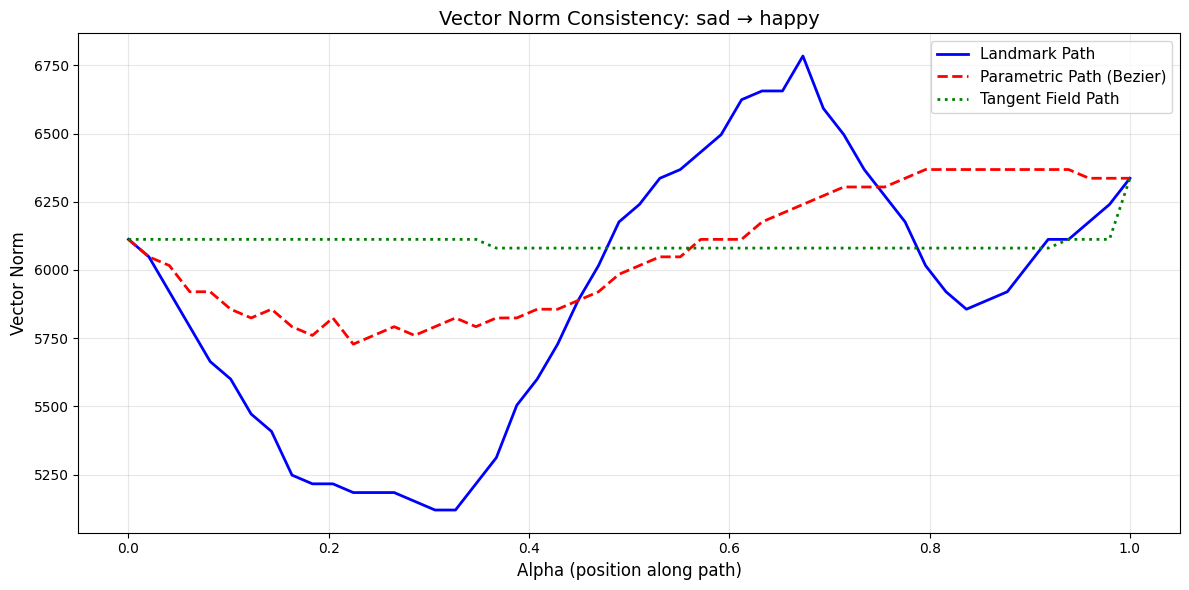

✅ Norm consistency plot created


In [19]:
print("\n🎨 Creating visualizations...")

# Sample paths at fine granularity
fine_alphas = np.linspace(0, 1, 50)

# Compute norms for each path representation
landmark_norms = [torch.norm(landmark_path.interpolate(a)).item() for a in fine_alphas]
parametric_norms = [torch.norm(parametric_path.interpolate(a)).item() for a in fine_alphas]
tangent_norms = [torch.norm(tangent_path.interpolate(a)).item() for a in fine_alphas]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(fine_alphas, landmark_norms, 'b-', label='Landmark Path', linewidth=2)
plt.plot(fine_alphas, parametric_norms, 'r--', label='Parametric Path (Bezier)', linewidth=2)
plt.plot(fine_alphas, tangent_norms, 'g:', label='Tangent Field Path', linewidth=2)
plt.xlabel('Alpha (position along path)', fontsize=12)
plt.ylabel('Vector Norm', fontsize=12)
plt.title(f'Vector Norm Consistency: {START_CONCEPT} → {END_CONCEPT}', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Norm consistency plot created")

## 4.2 Curvature Analysis

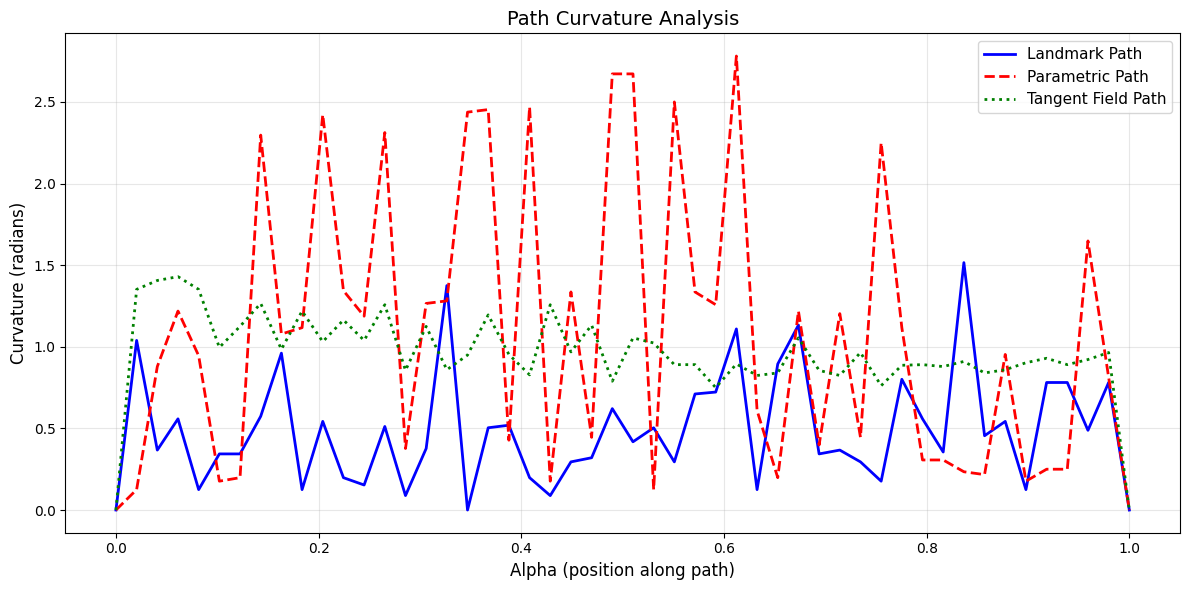

✅ Curvature analysis plot created


In [20]:
# Compute approximate curvature (rate of change of tangent direction)
def compute_curvature(path, alphas):
    """Compute curvature by measuring tangent direction change."""
    curvatures = []
    epsilon = 0.01
    
    for alpha in alphas[1:-1]:  # Skip endpoints
        v_before = path.interpolate(alpha - epsilon).flatten()
        v_center = path.interpolate(alpha).flatten()
        v_after = path.interpolate(alpha + epsilon).flatten()
        
        # Tangents
        t1 = torch.nn.functional.normalize(v_center - v_before, dim=0)
        t2 = torch.nn.functional.normalize(v_after - v_center, dim=0)
        
        # Angle between tangents
        dot = torch.clamp(torch.dot(t1, t2), -1.0, 1.0)
        angle = torch.acos(dot).item()
        
        curvatures.append(angle)
    
    return [0.0] + curvatures + [0.0]  # Pad endpoints

# Compute curvature for each path
landmark_curvature = compute_curvature(landmark_path, fine_alphas)
parametric_curvature = compute_curvature(parametric_path, fine_alphas)
tangent_curvature = compute_curvature(tangent_path, fine_alphas)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(fine_alphas, landmark_curvature, 'b-', label='Landmark Path', linewidth=2)
plt.plot(fine_alphas, parametric_curvature, 'r--', label='Parametric Path', linewidth=2)
plt.plot(fine_alphas, tangent_curvature, 'g:', label='Tangent Field Path', linewidth=2)
plt.xlabel('Alpha (position along path)', fontsize=12)
plt.ylabel('Curvature (radians)', fontsize=12)
plt.title('Path Curvature Analysis', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Curvature analysis plot created")

## 4.3 Summary Statistics

In [21]:
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

print(f"\n📊 Path Representations ({START_CONCEPT} → {END_CONCEPT}):")
print(f"\n  Landmark Path:")
print(f"    - Number of landmarks: {len(landmark_path.landmarks)}")
print(f"    - Norm range: {min(landmark_norms):.1f} - {max(landmark_norms):.1f}")
print(f"    - Average curvature: {np.mean(landmark_curvature):.4f} rad")

print(f"\n  Parametric Path (Bezier):")
print(f"    - Control points: {len(parametric_path.control_points)}")
print(f"    - Norm range: {min(parametric_norms):.1f} - {max(parametric_norms):.1f}")
print(f"    - Average curvature: {np.mean(parametric_curvature):.4f} rad")

print(f"\n  Tangent Field Path:")
print(f"    - Tangent samples: {len(tangent_path.tangent_vectors)}")
print(f"    - Norm range: {min(tangent_norms):.1f} - {max(tangent_norms):.1f}")
print(f"    - Stored curvatures: {tangent_path.curvatures}")

print(f"\n📊 Generalization Test ({TEST_CONCEPT_A} → {TEST_CONCEPT_B}):")
print(f"\n  Tested 3 representations × 3 methods = 9 combinations")
print(f"  See comparison tables above for semantic quality")

print(f"\n📊 Multi-Pair Learning:")
print(f"\n  Training pairs: {len(TRAINING_PAIRS)}")
print(f"  Universal representation: {aggregator.universal_representation['type']}")
print(f"  Unseen test: {UNSEEN_TEST_PAIR[0]} → {UNSEEN_TEST_PAIR[1]}")

print("\n" + "=" * 80)
print("\n✅ All experiments complete!")
print("\n🎉 Semantic Path Learning Lab finished successfully!")


SUMMARY STATISTICS

📊 Path Representations (sad → happy):

  Landmark Path:
    - Number of landmarks: 7
    - Norm range: 5120.0 - 6784.0
    - Average curvature: 0.4902 rad

  Parametric Path (Bezier):
    - Control points: 4
    - Norm range: 5728.0 - 6368.0
    - Average curvature: 1.0782 rad

  Tangent Field Path:
    - Tangent samples: 7
    - Norm range: 6080.0 - 6336.0
    - Stored curvatures: [0.0, 1.8359375, 1.90625, 1.71875, 2.234375, 2.203125, 0.0]

📊 Generalization Test (angry → calm):

  Tested 3 representations × 3 methods = 9 combinations
  See comparison tables above for semantic quality

📊 Multi-Pair Learning:

  Training pairs: 4
  Universal representation: tangent_field
  Unseen test: frustrated → satisfied


✅ All experiments complete!

🎉 Semantic Path Learning Lab finished successfully!


---

# 💡 Key Takeaways

## What We Learned:

### 1. **Path Representations**
- **LandmarkPath**: Piecewise slerp through extracted concept vectors
  - ✅ Direct, faithful to actual semantic space
  - ❌ Requires storage of all landmarks

- **ParametricCurvePath**: Smooth Bezier/spline/polynomial curves
  - ✅ Continuous, smooth transitions
  - ❌ May deviate from semantic manifold

- **TangentVectorFieldPath**: Direction field + curvature
  - ✅ Compact representation, captures flow
  - ❌ Requires numerical integration

### 2. **Generalization Methods**
- **Geometric Alignment**: Best when concept pairs have similar semantic structure
- **Relative Encoding**: Good for preserving relative positioning
- **Direction + Magnitude**: Natural for tangent field paths

### 3. **Multi-Pair Learning**
- Can extract universal transformation patterns
- Works best with semantically related concept pairs
- May not generalize to completely different semantic domains

## Next Steps:
- Try different layer combinations (extraction vs injection)
- Experiment with different keyword templates
- Test on non-emotional concepts
- Combine with vector arithmetic
- Use for model steering and generation control

---

**Questions? Findings?** Share your results and observations!

---

# 🎮 Custom Experiment Sandbox

Use this space for your own experiments!

In [ ]:
# Your custom experiments here!

# Example: Try a different concept pair
# custom_path = learn_semantic_path(
#     selfie,
#     "cold", "hot",
#     layer=EXTRACTION_LAYER,
#     num_steps=9,
#     template="intensity",
#     path_type="parametric"
# )